Name : Dhanashri S. Patil

Roll No : A51

PRN : 2324000466

Course : Deep Learning Lab

Assignment 6 : CNN And Transfer Learning for Maleria Detection


# ***Maleria Detection***

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten, Conv2D
from tensorflow.keras.models import Model
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.models import Sequential


In [ ]:
from glob import glob

In [ ]:
IMAGE_SIZE = [224,224]

train_path ='/content/drive/MyDrive/DL Lab/Maleria_Dataset/Train'
test_path ='/content/drive/MyDrive/DL Lab/Maleria_Dataset/Test'

In [ ]:
vgg = VGG16(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)

In [ ]:
for layers in vgg.layers:
  layers.trainable=False

In [ ]:
folders = glob('/content/drive/MyDrive/DL Lab/Maleria_Dataset/Train')


In [ ]:
folders

['/content/drive/MyDrive/DL Lab/Maleria_Dataset/Train']

In [ ]:
x = Flatten()(vgg.output)

In [ ]:
prediction = Dense(len(folders), activation='softmax')(x)
model = Model(inputs=vgg.input, outputs=prediction)

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        25,089 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,739,777 (56.23 MB)

 Trainable params: 25,089 (98.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
import tensorflow as tf
vgg_model = Sequential()
pretrained_model = tf.keras.applications.VGG16(include_top=False,input_shape=(224,224,3),pooling='max',weights='imagenet')
for layer in pretrained_model.layers:
    layer.trainable=False
vgg_model.add(pretrained_model)
vgg_model.add(Flatten())
vgg_model.add(Dense(512,activation='relu'))
vgg_model.add(Dense(2,activation='softmax'))

In [ ]:
vgg_model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

In [ ]:
train_datagen=ImageDataGenerator(
                rescale=1./255,
                shear_range=0.2,
                zoom_range=0.2,
                horizontal_flip=True
              )
test_datagen=ImageDataGenerator(
                rescale=1./255,
                shear_range=0.2,
                zoom_range=0.2,
                horizontal_flip=True
              )

In [ ]:
train_datagen

In [ ]:
test_datagen

In [ ]:
training_set=train_datagen.flow_from_directory('/content/drive/MyDrive/DL Lab/Maleria_Dataset/Train', target_size=(224,224), batch_size=32, class_mode='categorical')

Found 392 images belonging to 2 classes.


In [ ]:
test_set=test_datagen.flow_from_directory('/content/drive/MyDrive/DL Lab/Maleria_Dataset/Test', target_size=(224,224), batch_size=32, class_mode='categorical')

Found 91 images belonging to 2 classes.


In [ ]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
r=vgg_model.fit(training_set, validation_data=test_set, epochs=5)

Epoch 1/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 297s 23s/step - accuracy: 0.5510 - loss: 0.9187 - val_accuracy: 0.2527 - val_loss: 0.8017
Epoch 2/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 279s 22s/step - accuracy: 0.6429 - loss: 0.6169 - val_accuracy: 0.5934 - val_loss: 0.6459
Epoch 3/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 328s 22s/step - accuracy: 0.7577 - loss: 0.4990 - val_accuracy: 0.8462 - val_loss: 0.3852
Epoch 4/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 292s 23s/step - accuracy: 0.8036 - loss: 0.4446 - val_accuracy: 1.0000 - val_loss: 0.1618
Epoch 5/5
13/13 ━━━━━━━━━━━━━━━━━━━━ 330s 26s/step - accuracy: 0.8189 - loss: 0.4058 - val_accuracy: 0.8791 - val_loss: 0.3584


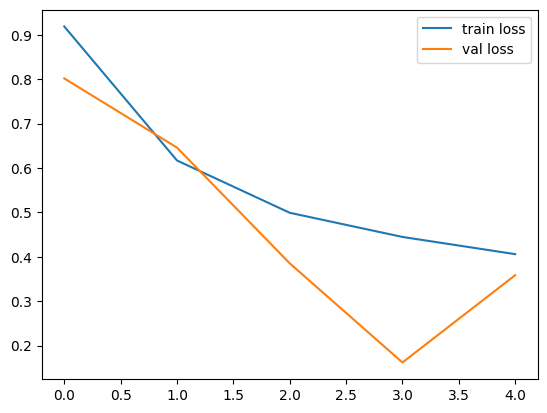

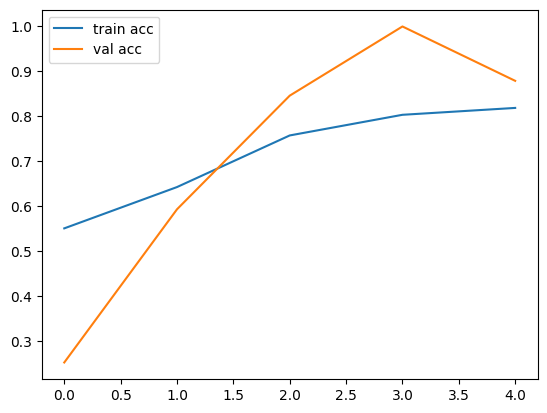

<Figure size 640x480 with 0 Axes>

In [ ]:
# plot the loss
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='val loss')
plt.legend()
plt.show()
plt.savefig('LossVal_loss')

# plot the accuracy
plt.plot(r.history['accuracy'], label='train acc')
plt.plot(r.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()
plt.savefig('AccVal_acc')

In [ ]:
from tensorflow.keras.models import load_model

vgg_model.save('vgg_model.h5')

In [ ]:
y_pred = vgg_model.predict(test_set)

3/3 ━━━━━━━━━━━━━━━━━━━━ 56s 18s/step


In [ ]:
import numpy as np
y_pred = np.argmax(y_pred, axis=1)

In [ ]:
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0])

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

In [ ]:
model = load_model('vgg_model.h5')

In [ ]:
img=image.load_img('/content/drive/MyDrive/DL Lab/Maleria_Dataset/Test/Parasite/C39P4thinF_original_IMG_20150622_105803_cell_110.png',target_size=(224,224))


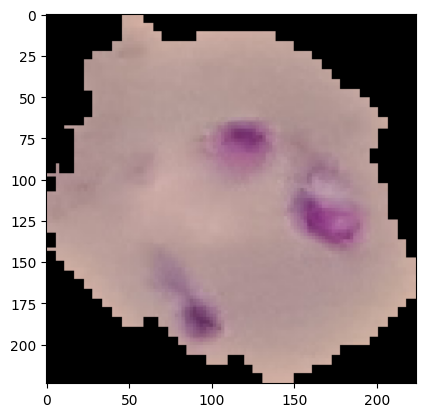

In [ ]:
plt.imshow(img)

In [ ]:
x=image.img_to_array(img)
x

array([[[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       ...,

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]],

       [[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        ...,
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]]], dtype=float32)

In [ ]:
x.shape

(224, 224, 3)

In [ ]:
x=x/255

In [ ]:
x.shape

(224, 224, 3)

In [ ]:
model.predict(np.expand_dims(x, axis=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 767ms/step


array([[0.82288617, 0.17711385]], dtype=float32)

In [ ]:
a=np.argmax(model.predict(np.expand_dims(x, axis=0)), axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 831ms/step


In [ ]:
if(a==0):
    print("Infected")
else:
    print("Uninfected")

Infected


# ***Case Study: - Medical Imaging Diagnosis with Limited Data***

In [ ]:
IMAGE_SIZE = [224,224]

In [ ]:
train_path = '/content/drive/MyDrive/DL Lab/Brain_Tumor_Dataset/Training'
test_path  = '/content/drive/MyDrive/DL Lab/Brain_Tumor_Dataset/Testing'


In [ ]:
vgg = VGG16(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)

In [ ]:
for layer in vgg.layers:
    layer.trainable = False

In [ ]:
folders = glob('/content/drive/MyDrive/DL Lab/Brain_Tumor_Dataset/Training/*')

In [ ]:
folders

['/content/drive/MyDrive/DL Lab/Brain_Tumor_Dataset/Training/notumor',
 '/content/drive/MyDrive/DL Lab/Brain_Tumor_Dataset/Training/pituitary',
 '/content/drive/MyDrive/DL Lab/Brain_Tumor_Dataset/Training/glioma',
 '/content/drive/MyDrive/DL Lab/Brain_Tumor_Dataset/Training/meningioma']

In [ ]:
x = Flatten()(vgg.output)
prediction = Dense(len(folders), activation='softmax')(x)

In [ ]:
model = Model(inputs=vgg.input, outputs=prediction)

In [ ]:
model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │       100,356 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,815,044 (56.51 MB)

 Trainable params: 100,356 (392.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
import tensorflow as tf

In [ ]:
vgg_model = Sequential()
pretrained_model = tf.keras.applications.VGG16(include_top=False,
                                               input_shape=(224,224,3),
                                               pooling='max',
                                               weights='imagenet')

In [ ]:
for layer in pretrained_model.layers:
    layer.trainable = False

In [ ]:
vgg_model.add(pretrained_model)
vgg_model.add(Flatten())
vgg_model.add(Dense(512, activation='relu'))
vgg_model.add(Dense(4, activation='softmax'))

In [ ]:
vgg_model.compile(loss='categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

In [ ]:
train_datagen = ImageDataGenerator(
                    rescale=1./255,
                    shear_range=0.2,
                    zoom_range=0.2,
                    horizontal_flip=True
                )

In [ ]:
test_datagen = ImageDataGenerator(
                    rescale=1./255
                )

In [ ]:
training_set = train_datagen.flow_from_directory(
                    train_path,
                    target_size=(224,224),
                    batch_size=32,
                    class_mode='categorical'
                )

Found 5600 images belonging to 4 classes.


In [ ]:
test_set = test_datagen.flow_from_directory(
                    test_path,
                    target_size=(224,224),
                    batch_size=32,
                    class_mode='categorical'
                )

Found 1600 images belonging to 4 classes.


In [ ]:
r = vgg_model.fit(
        training_set,
        validation_data=test_set,
        epochs=3
    )


Epoch 1/3
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 19s/step - accuracy: 0.6252 - loss: 0.9680 

In [ ]:
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='val loss')
plt.legend()
plt.show()
plt.savefig('LossVal_loss.png')


plt.plot(r.history['accuracy'], label='train acc')
plt.plot(r.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()
plt.savefig('AccVal_acc.png')

In [ ]:
from tensorflow.keras.models import load_model
vgg_model.save('vgg_model.h5')

In [ ]:
y_pred = vgg_model.predict(test_set)
y_pred = np.argmax(y_pred, axis=1)

In [ ]:
y_pred

In [ ]:
model = load_model('vgg_model.h5')

img_path = '/content/drive/MyDrive/DL Lab/Brain_Tumor_Dataset/Testing/meningioma/Te-aug-me_2.jpg'

img = image.load_img(img_path, target_size=(224,224))
plt.imshow(img)
plt.axis('off')


x = image.img_to_array(img)
x = x / 255
x = np.expand_dims(x, axis=0)


pred = model.predict(x)
pred_class = np.argmax(pred, axis=1)


class_labels = ['glioma', 'meningioma', 'notumor','pituitary']

print("Predicted Class:", class_labels[pred_class[0]])